#VARIATIONAL AUTOENCODERS
___

##0.REFERENCE AND CONTEXT

**Notebook Title: Variational Autoencoders for Generative Representation Learning with Fashion-MNIST**

**Introduction**

Variational Autoencoders, commonly known as VAEs, represent one of the most important milestones in the history of generative artificial intelligence. In the previous notebook, we studied denoising autoencoders, where the model learned to reconstruct clean images from noisy observations. That model learned a useful latent representation of the data, but it did not provide a principled mechanism for generating entirely new examples. The Variational Autoencoder introduces precisely that capability. Instead of merely compressing and reconstructing images, the VAE learns a probabilistic latent space from which new observations can be sampled and generated.

To understand why this matters, consider the difference between storing an image and understanding the distribution of images. A conventional autoencoder can compress an image into a latent vector and reconstruct it. However, if we randomly sample points in the latent space, many of those points may not correspond to meaningful images. The latent space can be fragmented, irregular, and difficult to navigate. The VAE addresses this limitation by forcing the latent representations to follow a structured probability distribution, typically a multivariate Gaussian distribution.

The key innovation of the VAE is that the encoder no longer produces a single latent vector. Instead, it produces two vectors: a vector of means and a vector of variances. These vectors define a probability distribution in latent space. During training, the model samples latent vectors from these distributions using a technique called the reparameterization trick. This allows gradients to propagate through the sampling process and enables end-to-end training using standard backpropagation.

The VAE optimization objective contains two distinct components. The first component is the reconstruction loss, which measures how well the generated output matches the original image. The second component is the Kullback-Leibler divergence, commonly called KL divergence. This term encourages the latent distributions learned by the encoder to remain close to a standard Gaussian distribution. The reconstruction term promotes accuracy, while the KL divergence promotes organization and smoothness in the latent space. Together, these objectives create a latent representation that is both meaningful and generative.

Fashion-MNIST is an ideal dataset for teaching VAEs. The dataset contains ten categories of clothing items represented as grayscale images of size twenty-eight by twenty-eight pixels. The images are simple enough to train quickly in Google Colab while still exhibiting sufficient visual diversity to demonstrate meaningful generative behavior. Students can observe how the model learns latent structure corresponding to shoes, bags, shirts, dresses, and other clothing categories.

This notebook follows the standard project format. We begin by preparing a GPU-optimized Colab environment using the permanent G4 template. We then load and preprocess Fashion-MNIST, construct the encoder and decoder networks, implement the reparameterization layer, define the VAE loss function, train the model, visualize reconstructions, explore the latent space, and generate entirely new synthetic images. Finally, GPT-5.2 will analyze the resulting artifacts and produce a governed explanation of the experiment.

By the end of this notebook, students will understand not only how a Variational Autoencoder works, but also why probabilistic latent spaces became one of the foundational ideas behind modern generative AI systems.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the Colab G4 environment. It detects GPU availability, enables TensorFlow memory growth, activates mixed precision when appropriate, establishes reproducible random seeds, creates artifact folders, and writes a run manifest. This template will be used throughout the remainder of the project.

In [8]:
# CELL 1
# G4/GPU-ready environment setup

import os
import json
import random
import platform
import datetime
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

physical_gpus = tf.config.list_physical_devices("GPU")
GPU_AVAILABLE = len(physical_gpus) > 0

if GPU_AVAILABLE:
    for gpu in physical_gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

    mixed_precision.set_global_policy("mixed_float16")
    COMPUTE_POLICY = "mixed_float16"
else:
    mixed_precision.set_global_policy("float32")
    COMPUTE_POLICY = "float32"

BATCH_SIZE = 512 if GPU_AVAILABLE else 128

PROJECT_DIR = Path("/content/vae_fashion_mnist_project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "models"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.datetime.now(
    datetime.timezone.utc
).strftime("run_%Y%m%d_%H%M%S_utc")

print("GPU Available:", GPU_AVAILABLE)
print("Policy:", COMPUTE_POLICY)
print("Batch Size:", BATCH_SIZE)
print("Run ID:", RUN_ID)

GPU Available: True
Policy: mixed_float16
Batch Size: 512
Run ID: run_20260605_164153_utc


##2.LOAD DATA

**Explanation for Cell 2**

This cell loads Fashion-MNIST and prepares the images for training. Pixel values are scaled into the zero-to-one range and reshaped to include a channel dimension suitable for convolutional processing.

In [9]:
# CELL 2

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


##3.VISUALIZATION

**Explanation for Cell 3**

This cell visualizes sample Fashion-MNIST images. Students should inspect the data before training. Understanding the input distribution is an essential step in every machine learning workflow.

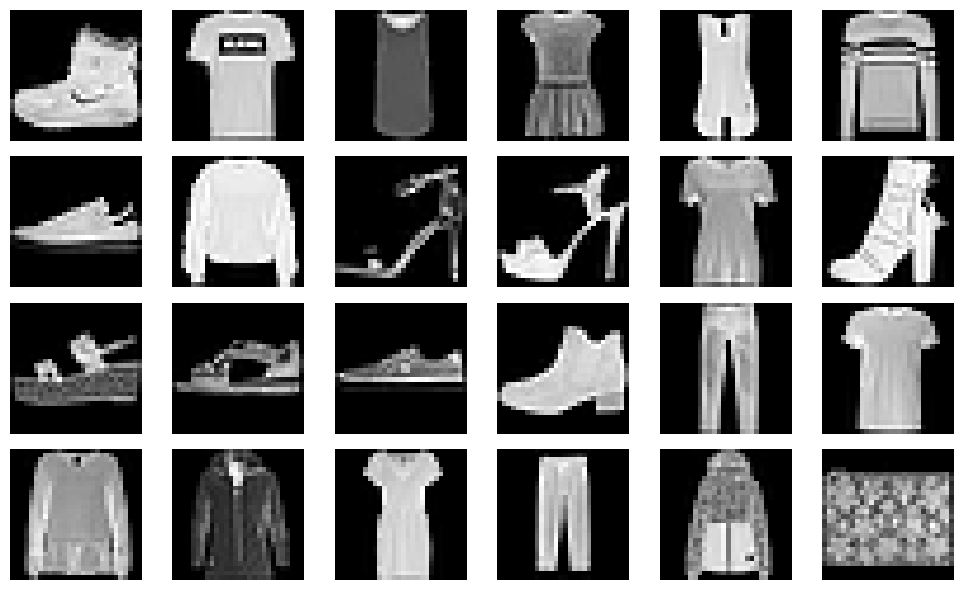

In [10]:
# CELL 3

plt.figure(figsize=(10, 6))

for i in range(24):
    plt.subplot(4, 6, i + 1)
    plt.imshow(X_train[i, :, :, 0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()
plt.close()

##4.THE ENCODER

**Explanation for Cell 4**

This cell constructs the encoder. Unlike a traditional autoencoder, the VAE encoder outputs two vectors: the latent mean and latent log variance. These parameters define the probability distribution associated with each input image.

In [11]:
# CELL 4

LATENT_DIM = 16

encoder_inputs = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)

print("Latent Dimension:", LATENT_DIM)

Latent Dimension: 16


##5.THE REPARAMETRIZATION TRICK

**Explanation for Cell 5**

This cell implements the reparameterization trick. Instead of sampling directly from the latent distribution, we express the sampling operation as a differentiable transformation. This allows gradients to propagate through the stochastic layer.

In [14]:
import tensorflow as tf

# CELL 5

class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs

        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        # Fix: Cast epsilon to the same dtype as z_mean and z_log_var
        epsilon = tf.random.normal(shape=(batch, dim), dtype=z_mean.dtype)

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3136)      │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    401,536 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      2,064 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      2,064 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_4          │ (None, 16)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 424,480 (1.62 MB)

 Trainable params: 424,480 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

##6.THE DECODER

**Explanation for Cell 6**

This cell builds the decoder. The decoder receives latent vectors and transforms them back into image space. The final output layer uses float32 to maintain numerical stability under mixed precision training.

In [15]:
# CELL 6

latent_inputs = keras.Input(shape=(LATENT_DIM,))

x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)

x = layers.Conv2DTranspose(
    64,
    3,
    strides=2,
    activation="relu",
    padding="same"
)(x)

x = layers.Conv2DTranspose(
    32,
    3,
    strides=2,
    activation="relu",
    padding="same"
)(x)

decoder_outputs = layers.Conv2D(
    1,
    3,
    activation="sigmoid",
    padding="same",
    dtype="float32"
)(x)

decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3136)           │        53,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,993 (425.75 KB)

 Trainable params: 108,993 (425.75 KB)

 Non-trainable params: 0 (0.00 B)

##7.THE VARIATIONAL AUTOENCODER CLASS

**Explanation for Cell 7**

This cell defines the Variational Autoencoder class. The training step computes both reconstruction loss and KL divergence. The total loss is the sum of these two objectives.

In [20]:
import tensorflow as tf

# CELL 7

class VAE(keras.Model):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    @tf.function
    def train_step(self, data):

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                )
            ) * (28 * 28)

            # Ensure z_mean and z_log_var are float32 for KL loss calculation
            # to avoid type mismatch with reconstruction_loss.
            z_mean_f32 = tf.cast(z_mean, tf.float32)
            z_log_var_f32 = tf.cast(z_log_var, tf.float32)

            kl_loss = -0.5 * tf.reduce_mean(
                1.0  # Ensure scalar 1 is float32
                + z_log_var_f32
                - tf.square(z_mean_f32)
                - tf.exp(z_log_var_f32)
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

vae = VAE(encoder, decoder)

##8.COMPILATION AND TRAINING

**Explanation for Cell 8**

This cell trains the Variational Autoencoder. Students should observe both reconstruction and KL divergence losses. These losses jointly shape the latent space.

In [19]:
# CELL 8

vae.compile(
    optimizer=keras.optimizers.Adam()
)

history = vae.fit(
    X_train,
    epochs=20,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - kl_loss: 2.8613 - loss: 298.4077 - reconstruction_loss: 295.5464
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - kl_loss: 3.1543 - loss: 246.4621 - reconstruction_loss: 243.3078
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - kl_loss: 3.2109 - loss: 237.2794 - reconstruction_loss: 234.0685
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - kl_loss: 3.1113 - loss: 233.1083 - reconstruction_loss: 229.9970
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - kl_loss: 3.1641 - loss: 230.1687 - reconstruction_loss: 227.0046
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - kl_loss: 3.1738 - loss: 228.2867 - reconstruction_loss: 225.1128
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - kl_loss: 3.1777 - loss: 227.0823 - reconstruction_loss: 223.9046
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - kl_loss: 3.1523 - loss: 226.0599 - reconstruction_loss: 222.9076
Epoch 9/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms

##9.VISUALIZATION

**Explanation for Cell 9**

This cell visualizes original images and reconstructed images. Static rendering is used to avoid blinking in Colab. Students can compare how well the VAE preserves visual structure.

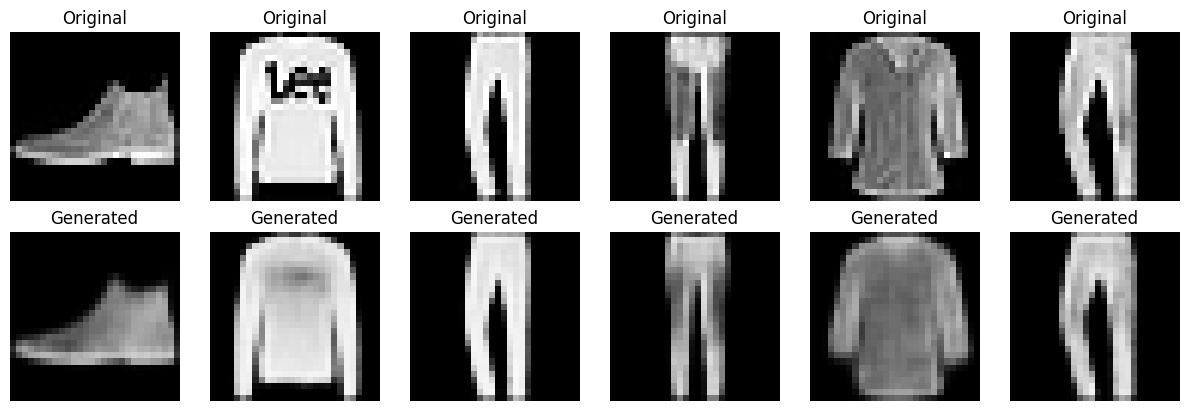

In [21]:
# CELL 9

z_mean_test, z_log_var_test, z_test = encoder.predict(
    X_test[:6],
    verbose=0
)

reconstructed = decoder.predict(
    z_test,
    verbose=0
)

fig, axes = plt.subplots(
    2,
    6,
    figsize=(12, 4),
    constrained_layout=True
)

for i in range(6):

    axes[0, i].imshow(
        X_test[i, :, :, 0],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")

    axes[1, i].imshow(
        reconstructed[i, :, :, 0],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1, i].axis("off")
    axes[1, i].set_title("Generated")

plt.show()
plt.close(fig)

##10.GENERATION OF NEW IMAGES

**Explanation for Cell 10**

This cell generates entirely new images by sampling random points from the latent Gaussian distribution. This is the defining capability of a Variational Autoencoder.

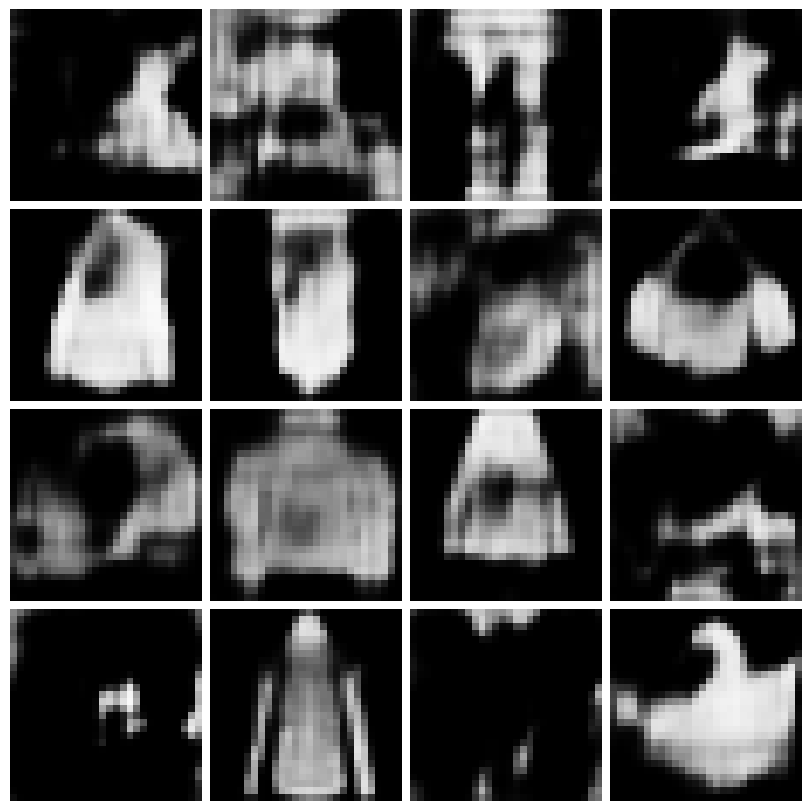

In [22]:
# CELL 10

latent_samples = np.random.normal(
    size=(16, LATENT_DIM)
)

generated_images = decoder.predict(
    latent_samples,
    verbose=0
)

fig, axes = plt.subplots(
    4,
    4,
    figsize=(8, 8),
    constrained_layout=True
)

for i in range(16):

    axes[i // 4, i % 4].imshow(
        generated_images[i, :, :, 0],
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[i // 4, i % 4].axis("off")

plt.show()
plt.close(fig)

##11.SUMMARIZATION AND EXPLANATION

**Explanation for the GPT-5.2 Results Cell**

This cell reads the experiment artifacts and asks GPT-5.2 to explain the meaning of the reconstruction quality, KL divergence, latent space organization, and image generation process. The output is requested as governed JSON.

In [23]:
# GPT-5.2 ANALYSIS CELL

from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get("OPENAI_API_KEY")
)

summary = {
    "epochs": len(history.history["loss"]),
    "final_loss": float(history.history["loss"][-1]),
    "latent_dimension": LATENT_DIM,
    "gpu_available": GPU_AVAILABLE,
    "mixed_precision": COMPUTE_POLICY
}

response = client.responses.create(
    model="gpt-5.2",
    input=f"""
Explain this Variational Autoencoder experiment.

Return JSON.

Experiment:

{json.dumps(summary, indent=2)}
"""
)

print(response.output_text)

```json
{
  "summary": "A Variational Autoencoder (VAE) was trained for 20 epochs using a 16-dimensional latent space, on a GPU with mixed-precision (float16) enabled. The reported final loss is ~220.11, which reflects the model’s combined reconstruction error and KL-divergence regularization at the end of training.",
  "what_each_field_means": {
    "epochs": "Number of full passes over the training dataset. Here, the model updated its weights across 20 complete dataset iterations.",
    "final_loss": "The VAE’s loss value at the end of training (typically reconstruction loss + KL divergence). Lower is better, but the absolute scale depends on the loss definition (sum vs mean), input dimensionality, batch size scaling, and the reconstruction likelihood used (e.g., Bernoulli/BCE vs Gaussian/MSE).",
    "latent_dimension": "Size of the compressed representation (z). A 16D latent space means the encoder maps each input to a 16D distribution (mean and variance), and the decoder reconstruc

##12.CONCLUSIONS

**Conclusion**

The Variational Autoencoder represents a major conceptual advance beyond traditional autoencoders. Whereas a standard autoencoder learns a deterministic mapping between an image and a latent representation, the VAE learns a probabilistic latent space. This difference transforms the model from a compression mechanism into a generative model capable of creating entirely new observations.

The key idea introduced in this notebook is the notion of a latent probability distribution. Instead of encoding each image as a single point, the encoder produces a mean vector and a variance vector. Together, these vectors define a Gaussian distribution within the latent space. By sampling from these distributions during training, the model learns a smooth and continuous representation of the underlying data-generating process.

The reparameterization trick is one of the most elegant ideas in modern machine learning. It allows stochastic sampling to coexist with gradient-based optimization. Without this technique, backpropagation could not pass through the sampling operation. By expressing sampling as a deterministic transformation of random noise, the VAE remains fully trainable using standard deep learning techniques.

The KL divergence term plays an equally important role. Reconstruction loss alone would encourage the model to memorize the training data. The KL divergence regularizes the latent space, encouraging it to remain close to a standard Gaussian distribution. This regularization creates a smooth latent manifold in which neighboring points correspond to similar images. As a result, random sampling becomes meaningful and interpolation becomes possible.

Fashion-MNIST provides an intuitive environment for observing these effects. Students can compare original images with reconstructed images and evaluate how well the model preserves visual structure. More importantly, they can generate entirely new images by sampling random latent vectors. These generated images demonstrate that the model has learned a representation of the distribution of clothing items rather than merely memorizing examples.

The notebook also demonstrated modern GPU-aware deep learning practices. Mixed precision, TensorFlow memory growth, GPU detection, dynamic batch sizing, and controlled static plotting ensure that the experiment runs efficiently on Colab G4 hardware while remaining reproducible and stable.

From a broader perspective, the Variational Autoencoder serves as a bridge between representation learning and generative artificial intelligence. Many modern generative systems build upon ideas introduced by VAEs, including latent-variable modeling, probabilistic representations, and structured generative spaces. Understanding the VAE therefore provides students with a conceptual foundation for more advanced generative architectures.

In the next notebook, we will study Generative Adversarial Networks. Whereas the VAE learns generation through probabilistic latent modeling, GANs learn generation through competition between a generator and a discriminator. Together, these two architectures form the foundation of modern generative deep learning.